# Testing different acquisition with direct reconstruction

In [1]:
# Import
import shutil
import torch
import tempfile
from pathlib import Path
from mrpro.data import KData  # Import the KData class
from mrpro.data.traj_calculators import KTrajectoryPulseq
from mrpro.data.SpatialDimension import SpatialDimension

import requests

# Local path
# US 93
h5_path1 = '/data/bouill01/PTBSequences/PTBSequences/seqfiles/final/meas_MID00095_FID06179_cartesian_2d_final_poiss_0_3_us_93_20240704_162827.h5'
seq_path1 = '/data/bouill01/PTBSequences/PTBSequences/seqfiles/final/cartesian_2d_final_poiss_0.3_us_93_20240704_162827.seq'
# US 256
h5_path2 = '/data/bouill01/PTBSequences/PTBSequences/seqfiles/final/meas_MID00097_FID06181_cartesian_2d_final_poiss_0_us_256_20240704_162847.h5'
seq_path2 = '/data/bouill01/PTBSequences/PTBSequences/seqfiles/final/cartesian_2d_final_poiss_0_us_256_20240704_162847.seq'
# US 26
h5_path3 = '/data/bouill01/PTBSequences/PTBSequences/seqfiles/final/meas_MID00093_FID06177_cartesian_2d_final_poiss_0_01_us_26_20240704_162837.h5'
seq_path3 = '/data/bouill01/PTBSequences/PTBSequences/seqfiles/final/cartesian_2d_final_poiss_0.01_us_26_20240704_162837.seq'
# US 46
h5_path4 = '/data/bouill01/PTBSequences/PTBSequences/seqfiles/final/meas_MID00094_FID06178_cartesian_2d_final_poiss_0_1_us_46_20240704_162906.h5'
seq_path4 = '/data/bouill01/PTBSequences/PTBSequences/seqfiles/final/cartesian_2d_final_poiss_0.1_us_46_20240704_162906.seq'
# US 141
h5_path5 = '/data/bouill01/PTBSequences/PTBSequences/seqfiles/final/meas_MID00096_FID06180_cartesian_2d_final_poiss_0_5_us_141_20240704_162804.h5'
seq_path5 = '/data/bouill01/PTBSequences/PTBSequences/seqfiles/final/cartesian_2d_final_poiss_0.5_us_141_20240704_162804.seq'

# 3D spirals
h5_path6 = '/data/bouill01/PTBSequences/PTBSequences/seqfiles/20240711_spiral_interleaved_3D_256mm_2012k0_3interleaves_golden_angle_3D/meas_MID00029_FID06362_20240711_spiral_interleaved_3D_256mm_2012k0_with_traj.h5'
seq_path6 = '/data/bouill01/PTBSequences/PTBSequences/seqfiles/20240711_spiral_interleaved_3D_256mm_2012k0_3interleaves_golden_angle_3D/20240711_spiral_interleaved_3D_256mm_2012k0_3interleaves_golden_angle_3D.seq'


# 3D spirals
h5_path7 = '/data/bouill01/PTBSequences/PTBSequences/seqfiles/3D_spirals/meas_MID00029_FID06362_20240711_spiral_interleaved_3D_256mm_2012k0_with_traj.h5'
seq_path7 = '/data/bouill01/PTBSequences/PTBSequences/seqfiles/3D_spirals/20240711_spiral_interleaved_3D_256mm_2012k0_3interleaves_golden_angle_3D.seq'

/home/bouill01/.conda/envs/mrpro_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Without Cartesian Sampling

In [2]:
import mrpro
from mrpro.data.traj_calculators import KTrajectoryIsmrmrd

# Use the trajectory that is stored in the ISMRMRD file
# trajectory = mrpro.data.traj_calculators.KTrajectoryIsmrmrd(seq_file)
# Load in the Data from the ISMRMRD file
kdatapuls = KData.from_file(h5_path5, KTrajectoryPulseq(seq_path=seq_path5))
kdatapuls.header.recon_matrix = SpatialDimension(z=1, y=256, x=256)
# Perform the reconstruction
reconstructionpuls = mrpro.algorithms.reconstruction.DirectReconstruction.from_kdata(kdatapuls)
# Use this to run on gpu: kdata = kdata.cuda()
img = reconstructionpuls(kdatapuls)

import matplotlib.pyplot as plt

# Display the reconstructed image
# If there are multiple slices, ..., only the first one is selected
first_img = img.rss().cpu()[0, 0, :, :]  #  images, z, y, x
plt.matshow(first_img, cmap='gray')

AttributeError: 'AdjointLinearOperator' object has no attribute '_operator2'

### With Cartesian Sampling

In [ ]:
# Create a CartesianSamplingOp using the encoding matrix and trajectory from kdata
encoding_matrix = kdatapuls.header.encoding_matrix
traj = kdatapuls.traj
cartesian_sampling_operator = mrpro.operators.CartesianSamplingOp(encoding_matrix, traj)

# Define the Fourier operator using the trajectory and header information in kdata
# Here we assume the k-space data is on a Cartesian grid
fourier_operator = mrpro.operators.FourierOp.from_kdata(kdatapuls)

# Combine the Cartesian sampling and Fourier operators
sampling_fourier_operator = cartesian_sampling_operator @ fourier_operator
adjoint_operator = sampling_fourier_operator.H

# Calculate coil maps using the adjoint operator
# Note that operators return a tuple of tensors, so we need to unpack it,
# even though there is only one tensor returned from the adjoint operator.
img_coilwise = mrpro.data.IData.from_tensor_and_kheader(*adjoint_operator(kdatapuls.data), kdatapuls.header)
csm_operator = mrpro.data.CsmData.from_idata_walsh(img_coilwise).as_operator()

# Perform Direct Reconstruction
forward_operator = sampling_fourier_operator @ csm_operator
adjoint_operator = forward_operator.H
img_manual = mrpro.data.IData.from_tensor_and_kheader(*adjoint_operator(kdatapuls.data), kdatapuls.header)

# Now you can use img_manual for further processing or visualization
# Display the reconstructed image
# If there are multiple slices, ..., only the first one is selected
first_img = img_manual.rss().cpu()[0, 0, :, :]  #  images, z, y, x
plt.matshow(first_img, cmap='gray')

AttributeError: 'AdjointLinearOperator' object has no attribute '_operator2'

### Without Cartesian Sampling

In [ ]:
import mrpro
from mrpro.data.traj_calculators import KTrajectoryIsmrmrd

# Use the trajectory that is stored in the ISMRMRD file
# trajectory = mrpro.data.traj_calculators.KTrajectoryIsmrmrd(seq_file)
# Load in the Data from the ISMRMRD file
kdatapuls = KData.from_file(h5_path2, KTrajectoryPulseq(seq_path=seq_path2))
kdatapuls.header.recon_matrix = SpatialDimension(z=1, y=256, x=256)
# Perform the reconstruction
reconstructionpuls = mrpro.algorithms.reconstruction.DirectReconstruction.from_kdata(kdatapuls)
# Use this to run on gpu: kdata = kdata.cuda()
img = reconstructionpuls(kdatapuls)

import matplotlib.pyplot as plt

# Display the reconstructed image
# If there are multiple slices, ..., only the first one is selected
first_img = img.rss().cpu()[0, 0, :, :]  #  images, z, y, x
plt.matshow(first_img, cmap='gray')

AttributeError: 'AdjointLinearOperator' object has no attribute '_operator2'

### Without Cartesian Sampling

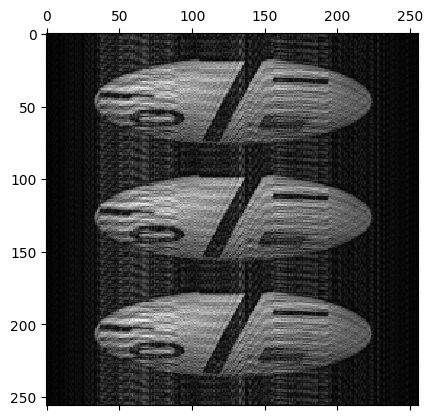

In [ ]:
import mrpro
from mrpro.data.traj_calculators import KTrajectoryIsmrmrd

# Use the trajectory that is stored in the ISMRMRD file
# trajectory = mrpro.data.traj_calculators.KTrajectoryIsmrmrd(seq_file)
# Load in the Data from the ISMRMRD file
kdatapuls = KData.from_file(h5_path3, KTrajectoryPulseq(seq_path=seq_path3))
kdatapuls.header.recon_matrix = SpatialDimension(z=1, y=256, x=256)
# Perform the reconstruction
reconstructionpuls = mrpro.algorithms.reconstruction.DirectReconstruction.from_kdata(kdatapuls)
# Use this to run on gpu: kdata = kdata.cuda()
img = reconstructionpuls(kdatapuls)

import matplotlib.pyplot as plt

# Display the reconstructed image
# If there are multiple slices, ..., only the first one is selected
first_img = img.rss().cpu()[0, 0, :, :]  #  images, z, y, x
plt.matshow(first_img, cmap='gray')

### With Cartesian Sampling

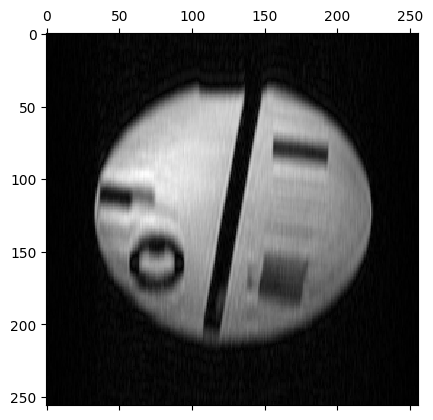

In [ ]:
# Import necessary modules
import torch
from mrpro.data import KData
from mrpro.data.SpatialDimension import SpatialDimension
from mrpro.data.KTrajectory import KTrajectory
from mrpro.operators.LinearOperator import LinearOperator

import mrpro

# Load in the Data from the ISMRMRD file
kdatapuls = KData.from_file(h5_path3, KTrajectoryPulseq(seq_path=seq_path3))
kdatapuls.header.recon_matrix = SpatialDimension(z=1, y=256, x=256)
kdatapuls.header.encoding_matrix = SpatialDimension(z=1, y=256*3, x=256)
# Create a CartesianSamplingOp using the encoding matrix and trajectory from kdata
encoding_matrix = kdatapuls.header.encoding_matrix
traj = kdatapuls.traj
cartesian_sampling_operator = mrpro.operators.CartesianSamplingOp(encoding_matrix, traj)

# Define the Fourier operator using the trajectory and header information in kdata
# Here we assume the k-space data is on a Cartesian grid
fourier_operator = mrpro.operators.FourierOp.from_kdata(kdatapuls)

# Combine the Cartesian sampling and Fourier operators
sampling_fourier_operator = cartesian_sampling_operator @ fourier_operator
adjoint_operator = sampling_fourier_operator.H

# Calculate coil maps using the adjoint operator
# Note that operators return a tuple of tensors, so we need to unpack it,
# even though there is only one tensor returned from the adjoint operator.
img_coilwise = mrpro.data.IData.from_tensor_and_kheader(*adjoint_operator(kdatapuls.data), kdatapuls.header)
csm_operator = mrpro.data.CsmData.from_idata_walsh(img_coilwise).as_operator()

# Perform Direct Reconstruction
forward_operator = sampling_fourier_operator @ csm_operator
adjoint_operator = forward_operator.H
img_manual = mrpro.data.IData.from_tensor_and_kheader(*adjoint_operator(kdatapuls.data), kdatapuls.header)

# Now you can use img_manual for further processing or visualization
# Display the reconstructed image
# If there are multiple slices, ..., only the first one is selected
first_img = img_manual.rss().cpu()[0, 0, :, :]  #  images, z, y, x
plt.matshow(first_img, cmap='gray')

In [ ]:
kdatapuls.data.shape

torch.Size([1, 4, 1, 26, 256])

### Without Cartesian Sampling

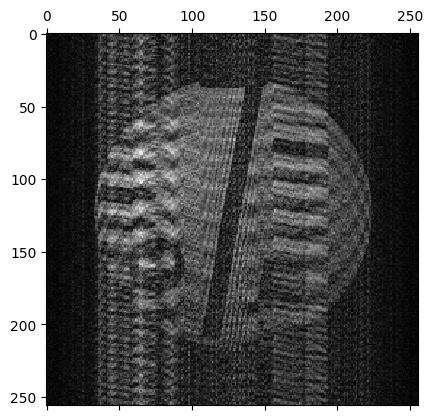

In [ ]:
import mrpro
from mrpro.data.traj_calculators import KTrajectoryIsmrmrd

# Use the trajectory that is stored in the ISMRMRD file
# trajectory = mrpro.data.traj_calculators.KTrajectoryIsmrmrd(seq_file)
# Load in the Data from the ISMRMRD file
kdatapuls = KData.from_file(h5_path4, KTrajectoryPulseq(seq_path=seq_path4))
kdatapuls.header.recon_matrix = SpatialDimension(z=1, y=256, x=256)
# Perform the reconstruction
reconstructionpuls = mrpro.algorithms.reconstruction.DirectReconstruction.from_kdata(kdatapuls)
# Use this to run on gpu: kdata = kdata.cuda()
img = reconstructionpuls(kdatapuls)

import matplotlib.pyplot as plt

# Display the reconstructed image
# If there are multiple slices, ..., only the first one is selected
first_img = img.rss().cpu()[0, 0, :, :]  #  images, z, y, x
plt.matshow(first_img, cmap='gray')

### With Cartesian Sampling

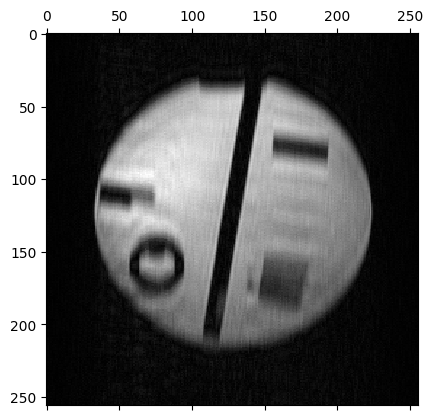

In [ ]:
# Create a CartesianSamplingOp using the encoding matrix and trajectory from kdata
encoding_matrix = kdatapuls.header.encoding_matrix
traj = kdatapuls.traj
cartesian_sampling_operator = mrpro.operators.CartesianSamplingOp(encoding_matrix, traj)

# Define the Fourier operator using the trajectory and header information in kdata
# Here we assume the k-space data is on a Cartesian grid
fourier_operator = mrpro.operators.FourierOp.from_kdata(kdatapuls)

# Combine the Cartesian sampling and Fourier operators
sampling_fourier_operator = cartesian_sampling_operator @ fourier_operator
adjoint_operator = sampling_fourier_operator.H

# Calculate coil maps using the adjoint operator
# Note that operators return a tuple of tensors, so we need to unpack it,
# even though there is only one tensor returned from the adjoint operator.
img_coilwise = mrpro.data.IData.from_tensor_and_kheader(*adjoint_operator(kdatapuls.data), kdatapuls.header)
csm_operator = mrpro.data.CsmData.from_idata_walsh(img_coilwise).as_operator()

# Perform Direct Reconstruction
forward_operator = sampling_fourier_operator @ csm_operator
adjoint_operator = forward_operator.H
img_manual = mrpro.data.IData.from_tensor_and_kheader(*adjoint_operator(kdatapuls.data), kdatapuls.header)

# Now you can use img_manual for further processing or visualization
# Display the reconstructed image
# If there are multiple slices, ..., only the first one is selected
first_img = img_manual.rss().cpu()[0, 0, :, :]  #  images, z, y, x
plt.matshow(first_img, cmap='gray')

### Without Cartesian Sampling

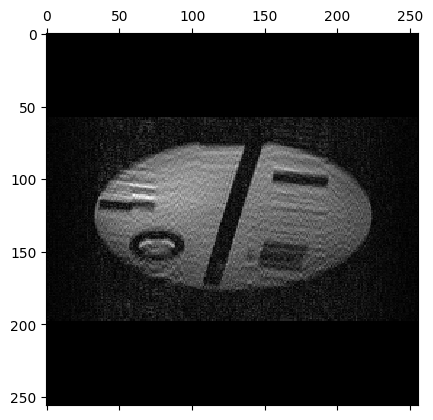

In [ ]:
import mrpro
from mrpro.data.traj_calculators import KTrajectoryIsmrmrd

# Use the trajectory that is stored in the ISMRMRD file
# trajectory = mrpro.data.traj_calculators.KTrajectoryIsmrmrd(seq_file)
# Load in the Data from the ISMRMRD file
kdatapuls = KData.from_file(h5_path5, KTrajectoryPulseq(seq_path=seq_path5))
kdatapuls.header.recon_matrix = SpatialDimension(z=1, y=256, x=256)
# Perform the reconstruction
reconstructionpuls = mrpro.algorithms.reconstruction.DirectReconstruction.from_kdata(kdatapuls)
# Use this to run on gpu: kdata = kdata.cuda()
img = reconstructionpuls(kdatapuls)

import matplotlib.pyplot as plt

# Display the reconstructed image
# If there are multiple slices, ..., only the first one is selected
first_img = img.rss().cpu()[0, 0, :, :]  #  images, z, y, x
plt.matshow(first_img, cmap='gray')

### With Cartesian Sampling

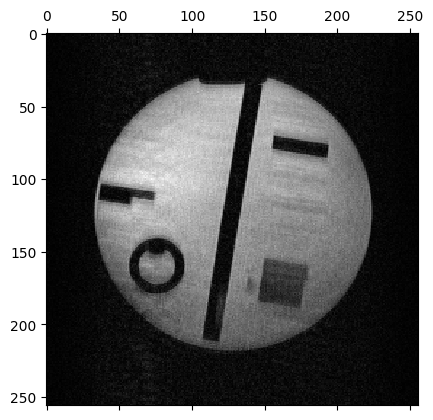

In [ ]:
# Create a CartesianSamplingOp using the encoding matrix and trajectory from kdata
encoding_matrix = kdatapuls.header.encoding_matrix
traj = kdatapuls.traj
cartesian_sampling_operator = mrpro.operators.CartesianSamplingOp(encoding_matrix, traj)

# Define the Fourier operator using the trajectory and header information in kdata
# Here we assume the k-space data is on a Cartesian grid
fourier_operator = mrpro.operators.FourierOp.from_kdata(kdatapuls)

# Combine the Cartesian sampling and Fourier operators
sampling_fourier_operator = cartesian_sampling_operator @ fourier_operator
adjoint_operator = sampling_fourier_operator.H

# Calculate coil maps using the adjoint operator
# Note that operators return a tuple of tensors, so we need to unpack it,
# even though there is only one tensor returned from the adjoint operator.
img_coilwise = mrpro.data.IData.from_tensor_and_kheader(*adjoint_operator(kdatapuls.data), kdatapuls.header)
csm_operator = mrpro.data.CsmData.from_idata_walsh(img_coilwise).as_operator()

# Perform Direct Reconstruction
forward_operator = sampling_fourier_operator @ csm_operator
adjoint_operator = forward_operator.H
img_manual = mrpro.data.IData.from_tensor_and_kheader(*adjoint_operator(kdatapuls.data), kdatapuls.header)

# Now you can use img_manual for further processing or visualization
# Display the reconstructed image
# If there are multiple slices, ..., only the first one is selected
first_img = img_manual.rss().cpu()[0, 0, :, :]  #  images, z, y, x
plt.matshow(first_img, cmap='gray')

In [ ]:
img_manual.data.shape

torch.Size([1, 1, 1, 256, 256])

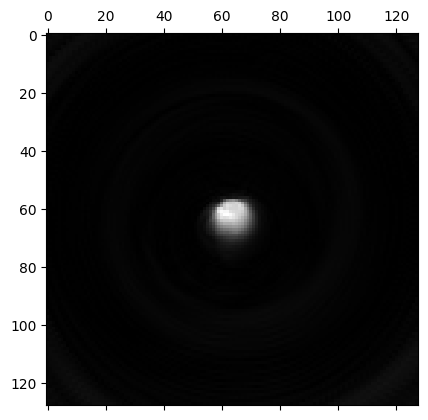

In [ ]:
import mrpro
from mrpro.data.traj_calculators import KTrajectoryIsmrmrd

# Use the trajectory that is stored in the ISMRMRD file
# trajectory = mrpro.data.traj_calculators.KTrajectoryIsmrmrd(seq_file)
# Load in the Data from the ISMRMRD file
kdatapuls = KData.from_file(h5_path6, KTrajectoryIsmrmrd())
kdatapuls.header.recon_matrix = SpatialDimension(z=16, y=128, x=128)
kdatapuls.header.encoding_matrix = SpatialDimension(z=16, y=128, x=128)
# # Perform the reconstruction
reconstructionpuls = mrpro.algorithms.reconstruction.DirectReconstruction.from_kdata(kdatapuls)
# Use this to run on gpu: kdata = kdata.cuda()
img = reconstructionpuls(kdatapuls)

import matplotlib.pyplot as plt

# Display the reconstructed image
# If there are multiple slices, ..., only the first one is selected
first_img = img.rss().cpu()[0, 0, :, :]  #  images, z, y, x
plt.matshow(first_img, cmap='gray')

Calculating for us_idx 1: tensor([[1]])


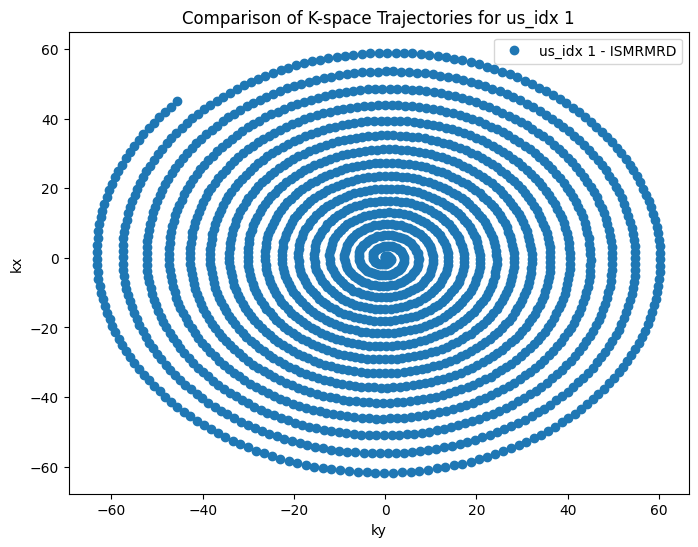

In [ ]:
import torch
from mrpro.data import KData
from mrpro.data.traj_calculators import KTrajectoryIsmrmrd, KTrajectoryPulseq
import matplotlib.pyplot as plt

# Load data from ISMRMRD file using KTrajectoryIsmrmrd
kdata_ismrmrd = KData.from_file(h5_path6, KTrajectoryIsmrmrd())


# Define values to compare for us_idx
us_idx_values = [torch.arange(1, 8,139)[None, :]]

# For each us_idx value, plot the first and last points of the k-space trajectory
for i, us_idx in enumerate(us_idx_values):
    print(f"Calculating for us_idx {i+1}:", us_idx)
    
    # Split k-space data into other dimensions based on undersampling indices
    kdata_us_ismrmrd = kdata_ismrmrd.split_k1_into_other(us_idx, other_label='repetition')

    # Plot k-space trajectory for ISMRMRD
    plt.figure(figsize=(8, 6))
    plt.plot(kdata_us_ismrmrd.traj.ky.flatten(), kdata_us_ismrmrd.traj.kx.flatten(), 'o', label=f'us_idx {i+1} - ISMRMRD')


    # Add labels and legend
    plt.xlabel('ky')
    plt.ylabel('kx')
    plt.title(f'Comparison of K-space Trajectories for us_idx {i+1}')
    plt.legend()
    plt.show()

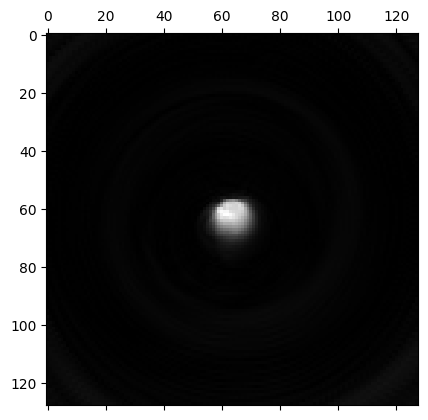

In [ ]:
import mrpro
from mrpro.data.traj_calculators import KTrajectoryIsmrmrd

# Use the trajectory that is stored in the ISMRMRD file
# trajectory = mrpro.data.traj_calculators.KTrajectoryIsmrmrd(seq_file)
# Load in the Data from the ISMRMRD file
kdatapuls = KData.from_file(h5_path7, KTrajectoryIsmrmrd())
kdatapuls.header.recon_matrix = SpatialDimension(z=16, y=128, x=128)
kdatapuls.header.encoding_matrix = SpatialDimension(z=16, y=128, x=128)
# # Perform the reconstruction
reconstructionpuls = mrpro.algorithms.reconstruction.DirectReconstruction.from_kdata(kdatapuls)
# Use this to run on gpu: kdata = kdata.cuda()
img = reconstructionpuls(kdatapuls)

import matplotlib.pyplot as plt

# Display the reconstructed image
# If there are multiple slices, ..., only the first one is selected
first_img = img.rss().cpu()[0, 0, :, :]  #  images, z, y, x
plt.matshow(first_img, cmap='gray')